# Week 06 · Day 3 — First ML Pipeline

## Baselines, Linear & Logistic Regression, and Metrics That Don't Lie

This notebook builds a complete, reproducible baseline-to-first-model ML pipeline using the same `students` dataset from Monday.

### Objectives
- Create model-ready features using one-hot encoding.
- Use the exact required train/test split for regression.
- Compare a mean regression baseline with Linear Regression using RMSE and R².
- Inspect Linear Regression coefficients.
- Create a binary `distinction` target (`exam_score >= 85`).
- Compare a majority-class classification baseline with Logistic Regression using accuracy, precision, recall, and F1.
- Keep the workflow reproducible with fixed random seeds.


## 1. Imports and Reproducibility

All randomness used to regenerate the dataset and split the data is explicitly seeded.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

RANDOM_SEED = 21
SPLIT_SEED = 42


## 2. Regenerate the Monday `students` Dataset

This follows the exact dataset specification from Monday: `seed=21`, `n=600`, sections A/B/C, study hours, sleep hours, attendance, and exam score.


In [2]:
rng = np.random.default_rng(seed=21)
n = 600

class_section = rng.choice(["A", "B", "C"], size=n, p=[0.34, 0.33, 0.33])
study_hours = rng.normal(10, 3.5, size=n).clip(0, None).round(1)
sleep_hours = rng.normal(7, 1.2, size=n).clip(3, 10).round(1)
attendance_pct = rng.normal(85, 10, size=n).clip(40, 100).round(1)

noise = rng.normal(0, 8, size=n)
section_bonus = pd.Series(class_section).map({"A": 0, "B": 0, "C": 4}).values
exam_score = (
    50
    + 2.6 * study_hours
    + 0.15 * attendance_pct
    + section_bonus
    + noise
).clip(0, 100).round(1)

students = pd.DataFrame({
    "student_id": np.arange(1, n + 1),
    "class_section": class_section,
    "study_hours_per_week": study_hours,
    "sleep_hours_per_night": sleep_hours,
    "attendance_pct": attendance_pct,
    "exam_score": exam_score,
})

students.head()


,student_id,class_section,study_hours_per_week,sleep_hours_per_night,attendance_pct,exam_score
0,1,C,11.0,7.3,89.4,100.0
1,2,B,9.1,7.7,72.4,72.2
2,3,C,2.2,8.5,84.6,67.2
3,4,A,13.5,7.5,83.4,100.0
4,5,B,11.0,5.4,100.0,100.0


## 3. Data Quality Check

Before building the ML pipeline, we first check whether the dataset is clean and ready for modeling.

We will check:
- Dataset shape
- Data types
- Missing values
- Duplicate rows
- Basic descriptive statistics
- Unique values in categorical columns
- Valid ranges of numerical columns

This step helps us identify any data quality issues before feature engineering and model training.

In [3]:
# Dataset shape
print("Dataset shape:", students.shape)

# Data types
print("\nData types:")
print(students.dtypes)

# Missing values
print("\nMissing values:")
print(students.isnull().sum())

# Duplicate rows
print("\nDuplicate rows:", students.duplicated().sum())

# Descriptive statistics
print("\nDescriptive statistics:")
display(students.describe())

# Unique values in categorical column
print("\nClass section values:")
print(students["class_section"].value_counts().sort_index())

# Validity checks
print("\nValidity checks:")

print(
    "Study hours below 0:",
    (students["study_hours_per_week"] < 0).sum()
)

print(
    "Sleep hours outside 3–10:",
    (
        (students["sleep_hours_per_night"] < 3)
        | (students["sleep_hours_per_night"] > 10)
    ).sum()
)

print(
    "Attendance outside 40–100:",
    (
        (students["attendance_pct"] < 40)
        | (students["attendance_pct"] > 100)
    ).sum()
)

print(
    "Exam scores outside 0–100:",
    (
        (students["exam_score"] < 0)
        | (students["exam_score"] > 100)
    ).sum()
)

Dataset shape: (600, 6)

Data types:
student_id                 int64
class_section             object
study_hours_per_week     float64
sleep_hours_per_night    float64
attendance_pct           float64
exam_score               float64
dtype: object

Missing values:
student_id               0
class_section            0
study_hours_per_week     0
sleep_hours_per_night    0
attendance_pct           0
exam_score               0
dtype: int64

Duplicate rows: 0

Descriptive statistics:


,student_id,study_hours_per_week,sleep_hours_per_night,attendance_pct,exam_score
count,600.000000,600.000000,600.000000,600.000000,600.000000
mean,300.500000,10.089333,7.046000,85.583000,88.605000
std,173.349358,3.407213,1.122787,9.137597,10.205279
min,1.000000,0.400000,3.400000,62.000000,58.900000
25%,150.750000,7.700000,6.275000,78.900000,81.750000
50%,300.500000,10.000000,7.100000,85.700000,90.200000
75%,450.250000,12.500000,7.800000,92.325000,98.700000
max,600.000000,21.900000,10.000000,100.000000,100.000000



Class section values:
class_section
A    212
B    198
C    190
Name: count, dtype: int64

Validity checks:
Study hours below 0: 0
Sleep hours outside 3–10: 0
Attendance outside 40–100: 0
Exam scores outside 0–100: 0


## 4. Short Exploratory Data Analysis

A short EDA is performed to understand the main patterns in the dataset before feature engineering.

We will examine:
- The distribution of students across class sections
- The correlation of numerical features with exam score

This provides a quick understanding of the data and helps guide the upcoming feature engineering step.

In [4]:
students["class_section"].value_counts().sort_index()

class_section
A    212
B    198
C    190
Name: count, dtype: int64

In [5]:
# Calculate correlations
corr = students[
    [
        "study_hours_per_week",
        "sleep_hours_per_night",
        "attendance_pct",
        "exam_score",
    ]
].corr()["exam_score"]

study_r = corr["study_hours_per_week"]
attendance_r = corr["attendance_pct"]
sleep_r = corr["sleep_hours_per_night"]

print(f"Study hours correlation: {study_r:.4f}")
print(f"Attendance correlation: {attendance_r:.4f}")
print(f"Sleep hours correlation: {sleep_r:.4f}")

Study hours correlation: 0.6895
Attendance correlation: 0.1066
Sleep hours correlation: -0.0217


In [6]:
print(
    f"- Study hours have the strongest positive correlation with exam score "
    f"(r = {study_r:.4f})."
)

print(
    f"- Attendance has a weak positive correlation with exam score "
    f"(r = {attendance_r:.4f})."
)

print(
    f"- Sleep hours have an almost negligible correlation with exam score "
    f"(r = {sleep_r:.4f})."
)

- Study hours have the strongest positive correlation with exam score (r = 0.6895).
- Attendance has a weak positive correlation with exam score (r = 0.1066).
- Sleep hours have an almost negligible correlation with exam score (r = -0.0217).


## 5. Feature Engineering

`class_section` is categorical, so it is converted into numerical indicator columns using one-hot encoding with `drop_first=True`.

The required feature matrix contains:
- `study_hours_per_week`
- `sleep_hours_per_night`
- `attendance_pct`
- two encoded section columns


In [7]:
X = pd.get_dummies(
    students[
        [
            "class_section",
            "study_hours_per_week",
            "sleep_hours_per_night",
            "attendance_pct",
        ]
    ],
    columns=["class_section"],
    drop_first=True,
    dtype=int,
)

y = students["exam_score"]

print("Feature columns:")
print(X.columns.tolist())
print("\nFeature matrix shape:", X.shape)
X.head()


Feature columns:
['study_hours_per_week', 'sleep_hours_per_night', 'attendance_pct', 'class_section_B', 'class_section_C']

Feature matrix shape: (600, 5)


,study_hours_per_week,sleep_hours_per_night,attendance_pct,class_section_B,class_section_C
0,11.0,7.3,89.4,0,1
1,9.1,7.7,72.4,1,0
2,2.2,8.5,84.6,0,1
3,13.5,7.5,83.4,0,0
4,11.0,5.4,100.0,1,0


## Feature Engineering Interpretation

- The feature matrix contains **600 rows and 5 features**, confirming that the dataset has been successfully prepared for machine learning.
- The numerical features `study_hours_per_week`, `sleep_hours_per_night`, and `attendance_pct` were kept unchanged as input features.
- The categorical `class_section` variable was converted into two binary features: `class_section_B` and `class_section_C` using one-hot encoding.
- `drop_first=True` makes **Section A the reference category**, so students from Section A are represented by `0` in both encoded columns.
- The target variable `exam_score` is stored separately in `y`, while `X` contains only the predictor features.

## 6. Regression Train/Test Split

Use the exact required split:

`train_test_split(X, y, test_size=0.2, random_state=42)`

The same split is used for both the regression baseline and Linear Regression so their scores are directly comparable.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")


Training rows: 480
Test rows: 120


## Train-Test Split Interpretation

- The dataset was divided into **training and testing sets**.
- The training set contains **80% of the data**, while the test set contains **20% of the data**.
- The training data will be used to **train the machine learning model**.
- The test data will be used to **evaluate the model on unseen data**.
- `random_state=42` ensures that the same split can be reproduced when the code is run again.

## 7. Regression Baseline — Mean Predictor

The baseline predicts the **training-set mean** for every test observation.

A real regression model must beat this baseline. We evaluate it using:
- **RMSE:** lower is better; it is measured in exam-score points.
- **R²:** higher is better; `0` corresponds to mean-baseline performance.


In [9]:
reg_baseline = DummyRegressor(strategy="mean")
reg_baseline.fit(X_train, y_train)

baseline_pred = reg_baseline.predict(X_test)

baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print(f"Regression baseline RMSE: {baseline_rmse:.4f}")
print(f"Regression baseline R²:   {baseline_r2:.4f}")


Regression baseline RMSE: 10.2978
Regression baseline R²:   -0.0096


## Regression Baseline Interpretation

- A `DummyRegressor` with the mean strategy was used to establish a simple baseline for regression.
- The baseline predicts the same average exam score for every student in the test set.
- The RMSE shows the typical prediction error of the baseline model in exam-score units.
- The R² value is slightly negative, indicating that the baseline model does not explain the variation in exam scores and performs slightly worse than a constant mean-based reference.
- This baseline provides a reference point for comparing the performance of more advanced regression models.

## 8. Linear Regression

Train a Linear Regression model on the same training data and evaluate it on the same held-out test set.


In [10]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

rmse_improvement = baseline_rmse - linear_rmse
r2_improvement = linear_r2 - baseline_r2

print(f"Linear Regression RMSE: {linear_rmse:.4f}")
print(f"Linear Regression R²:   {linear_r2:.4f}")
print(f"RMSE improvement:       {rmse_improvement:.4f} points")
print(f"R² improvement:         {r2_improvement:.4f}")


Linear Regression RMSE: 7.0584
Linear Regression R²:   0.5257
RMSE improvement:       3.2394 points
R² improvement:         0.5353


## Linear Regression Interpretation

- A Linear Regression model was trained using the training data and evaluated on the unseen test data.
- The model achieved a lower RMSE than the baseline, indicating that its predictions have less error than the simple mean-based approach.
- The positive R² indicates that the Linear Regression model explains a meaningful portion of the variation in exam scores.
- The positive RMSE improvement confirms that Linear Regression reduced prediction error compared with the baseline model.
- The positive R² improvement shows that Linear Regression provides a substantially better fit than the baseline.
- Overall, the Linear Regression model performs better than the baseline and provides a stronger starting point for predicting exam scores.

In [11]:
regression_comparison = pd.DataFrame({
    "Model": ["Dummy Mean Baseline", "Linear Regression"],
    "RMSE": [baseline_rmse, linear_rmse],
    "R²": [baseline_r2, linear_r2],
})

regression_comparison


,Model,RMSE,R²
0,Dummy Mean Baseline,10.297789,-0.009560
1,Linear Regression,7.058359,0.525702


### Regression Interpretation

The Linear Regression model should have a **lower RMSE** and a **higher R²** than the mean baseline. The RMSE difference shows how many exam-score points were gained over the baseline, while the R² difference shows the additional variance explained by the real model.


In [12]:
from pathlib import Path

Path("Figures").mkdir(parents=True, exist_ok=True)

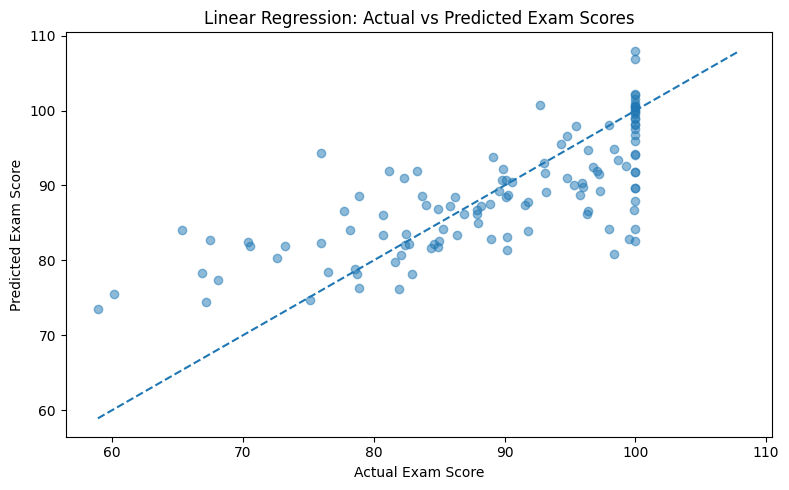

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(y_test, linear_pred, alpha=0.5)

min_score = min(y_test.min(), linear_pred.min())
max_score = max(y_test.max(), linear_pred.max())

ax.plot(
    [min_score, max_score],
    [min_score, max_score],
    linestyle="--"
)

ax.set_title("Linear Regression: Actual vs Predicted Exam Scores")
ax.set_xlabel("Actual Exam Score")
ax.set_ylabel("Predicted Exam Score")

fig.tight_layout()
fig.savefig("Figures/linear_actual_vs_predicted.png", bbox_inches="tight")
plt.show()

## 9. Inspect Linear Regression Coefficients

The coefficients show how each feature changes the predicted exam score while the other features are held constant.

We print the coefficients next to their feature names and identify the feature with the largest absolute effect.


In [14]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_,
})

coefficients["Absolute_Effect"] = coefficients["Coefficient"].abs()
coefficients = coefficients.sort_values("Absolute_Effect", ascending=False)

print("Linear Regression coefficients:")
display(coefficients)

largest_effect = coefficients.iloc[0]
print(
    f"Largest absolute coefficient: {largest_effect['Feature']} "
    f"({largest_effect['Coefficient']:.4f})"
)


Linear Regression coefficients:


,Feature,Coefficient,Absolute_Effect
4,class_section_C,3.130369,3.130369
0,study_hours_per_week,2.032957,2.032957
3,class_section_B,0.124836,0.124836
2,attendance_pct,0.088670,0.088670
1,sleep_hours_per_night,-0.010655,0.010655


Largest absolute coefficient: class_section_C (3.1304)


In [15]:
print("## Coefficient Interpretation")
print(
    f"- The feature with the largest absolute coefficient is "
    f"{largest_effect['Feature']} ({largest_effect['Coefficient']:.4f})."
)
print(
    f"- Its positive coefficient indicates a positive effect on the predicted "
    f"exam score, while keeping other features constant."
)
print(
    f"- The coefficient for study_hours_per_week is "
    f"{coefficients.loc[coefficients['Feature'] == 'study_hours_per_week', 'Coefficient'].iloc[0]:.4f}, "
    f"indicating that study hours have a positive relationship with predicted exam score."
)
print(
    f"- The coefficient for sleep_hours_per_night is "
    f"{coefficients.loc[coefficients['Feature'] == 'sleep_hours_per_night', 'Coefficient'].iloc[0]:.4f}, "
    f"indicating a very small effect in this fitted model."
)
print(
    f"- Overall, the coefficient magnitudes suggest that "
    f"{largest_effect['Feature']} has the strongest fitted effect among the included features."
)

## Coefficient Interpretation
- The feature with the largest absolute coefficient is class_section_C (3.1304).
- Its positive coefficient indicates a positive effect on the predicted exam score, while keeping other features constant.
- The coefficient for study_hours_per_week is 2.0330, indicating that study hours have a positive relationship with predicted exam score.
- The coefficient for sleep_hours_per_night is -0.0107, indicating a very small effect in this fitted model.
- Overall, the coefficient magnitudes suggest that class_section_C has the strongest fitted effect among the included features.


## Intercept Analysis

The intercept is the constant term of the Linear Regression model. It represents the baseline value of the model when all input features are set to zero.

Calculating the intercept helps us understand the complete Linear Regression equation and how the model combines the intercept with the feature coefficients to make predictions.

The intercept is mainly a mathematical starting point and should not necessarily be interpreted as a realistic exam score, because a student with all features equal to zero may not represent a meaningful real-world case.

In [16]:
intercept = linear_model.intercept_

print(f"Linear Regression intercept: {intercept:.4f}")

Linear Regression intercept: 59.4341


## Intercept Interpretation

- The Linear Regression model has a positive intercept, which represents the constant term of the regression equation.
- The intercept serves as the model's baseline value before the effects of the input features are added.
- It should not be interpreted as an actual expected exam score because a student with all input features equal to zero is not a meaningful real-world case.
- The intercept, together with the feature coefficients, forms the complete Linear Regression model used to generate exam score predictions.

## 10. Classification Target — Distinction

Create a binary target:

- `1` if `exam_score >= 85`
- `0` otherwise

The fraction of students reaching 85 is important because it tells us how balanced the target is and helps us interpret accuracy.


In [17]:
students["distinction"] = (students["exam_score"] >= 85).astype(int)

distinction_fraction = students["distinction"].mean()
class_counts = students["distinction"].value_counts().sort_index()

print(f"Fraction reaching distinction (>= 85): {distinction_fraction:.4f}")
print(f"Percentage reaching distinction: {distinction_fraction * 100:.2f}%")
print("\nClass counts:")
print(class_counts)


Fraction reaching distinction (>= 85): 0.6533
Percentage reaching distinction: 65.33%

Class counts:
distinction
0    208
1    392
Name: count, dtype: int64


## Distinction Classification

The `distinction` variable converts the continuous exam score into a binary classification target.

Students with an exam score of 85 or above are assigned `1` (distinction), while students scoring below 85 are assigned `0`.

The results show that the majority of students reached the distinction threshold. The dataset contains both classes, with 392 students classified as distinction and 208 students classified as non-distinction.

This binary target can be used later to build a classification model that predicts whether a student will achieve distinction based on their study habits, sleep, attendance, and class section.

## 11. Classification Train/Test Split

For classification, use a **fresh stratified split**. `stratify=y_class` keeps approximately the same class balance in both training and test sets.

The features remain exactly the same model-ready matrix created earlier.


In [18]:
y_class = students["distinction"]

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class,
)

print("Training rows:", len(X_train_cls))
print("Test rows:", len(X_test_cls))
print(f"Training distinction rate: {y_train_cls.mean():.4f}")
print(f"Test distinction rate:     {y_test_cls.mean():.4f}")


Training rows: 480
Test rows: 120
Training distinction rate: 0.6542
Test distinction rate:     0.6500


In [19]:
print(
    f"The training set contains {len(X_train_cls)} students "
    f"({len(X_train_cls) / len(X) * 100:.0f}% of the data), "
    f"while the test set contains {len(X_test_cls)} students "
    f"({len(X_test_cls) / len(X) * 100:.0f}% of the data)."
)

print(
    f"The distinction rate is {y_train_cls.mean() * 100:.2f}% in training "
    f"and {y_test_cls.mean() * 100:.2f}% in testing, "
    f"showing that stratification maintained a similar class distribution."
)

The training set contains 480 students (80% of the data), while the test set contains 120 students (20% of the data).
The distinction rate is 65.42% in training and 65.00% in testing, showing that stratification maintained a similar class distribution.


## 12. Classification Baseline — Most Frequent Class

The classification baseline predicts the most frequent class for every observation.

We calculate:
- **Accuracy:** overall fraction correct.
- **Precision:** among predicted positives, how many are actually positive.
- **Recall:** among actual positives, how many are detected.
- **F1:** harmonic mean of precision and recall.


In [20]:
cls_baseline = DummyClassifier(strategy="most_frequent")
cls_baseline.fit(X_train_cls, y_train_cls)

baseline_cls_pred = cls_baseline.predict(X_test_cls)

baseline_accuracy = accuracy_score(y_test_cls, baseline_cls_pred)
baseline_precision = precision_score(
    y_test_cls, baseline_cls_pred, zero_division=0
)
baseline_recall = recall_score(
    y_test_cls, baseline_cls_pred, zero_division=0
)
baseline_f1 = f1_score(
    y_test_cls, baseline_cls_pred, zero_division=0
)

print(f"Baseline accuracy:  {baseline_accuracy:.4f}")
print(f"Baseline precision: {baseline_precision:.4f}")
print(f"Baseline recall:    {baseline_recall:.4f}")
print(f"Baseline F1:        {baseline_f1:.4f}")


Baseline accuracy:  0.6500
Baseline precision: 0.6500
Baseline recall:    1.0000
Baseline F1:        0.7879


## Classification Baseline Interpretation

The baseline classifier uses the `most_frequent` strategy, meaning it always predicts the most common class in the training data.

The model provides a simple reference point for evaluating more advanced classification models. Its performance reflects the class distribution rather than learning meaningful relationships between the input features and distinction status.

The baseline achieves reasonable accuracy because distinction is the majority class. However, its recall is perfect because it predicts every test student as a distinction student. This also means that it cannot identify students who do not reach the distinction threshold.

Therefore, this baseline provides a useful benchmark, but it is not a meaningful predictive model.

### Why Accuracy Alone Can Mislead

If one class is more common than the other, a model can obtain a respectable accuracy simply by predicting the majority class every time. In that situation, precision, recall, and F1 expose the fact that the baseline is not actually identifying the positive class.


## 13. Logistic Regression

Now train a real Logistic Regression model on the same classification features and compare all four metrics directly against the baseline.


In [21]:
logistic_model = LogisticRegression(
    random_state=RANDOM_SEED,
    max_iter=1000,
)

logistic_model.fit(X_train_cls, y_train_cls)

logistic_pred = logistic_model.predict(X_test_cls)

logistic_accuracy = accuracy_score(y_test_cls, logistic_pred)
logistic_precision = precision_score(
    y_test_cls, logistic_pred, zero_division=0
)
logistic_recall = recall_score(
    y_test_cls, logistic_pred, zero_division=0
)
logistic_f1 = f1_score(
    y_test_cls, logistic_pred, zero_division=0
)

print(f"Logistic Regression accuracy:  {logistic_accuracy:.4f}")
print(f"Logistic Regression precision: {logistic_precision:.4f}")
print(f"Logistic Regression recall:    {logistic_recall:.4f}")
print(f"Logistic Regression F1:        {logistic_f1:.4f}")


Logistic Regression accuracy:  0.7667
Logistic Regression precision: 0.8125
Logistic Regression recall:    0.8333
Logistic Regression F1:        0.8228


## Logistic Regression Interpretation

Logistic Regression is trained to predict whether a student reaches the distinction threshold based on the available features.

The model performs better than the most-frequent baseline because it learns relationships between the input features and the binary distinction target.

The accuracy, precision, recall, and F1-score provide different views of classification performance. In particular, precision measures the correctness of distinction predictions, while recall measures how many actual distinction students are correctly identified.

Although recall is lower than the baseline, Logistic Regression provides a better overall balance between precision and recall and can also distinguish between distinction and non-distinction students.

In [22]:
classification_comparison = pd.DataFrame({
    "Model": ["Dummy Most-Frequent Baseline", "Logistic Regression"],
    "Accuracy": [baseline_accuracy, logistic_accuracy],
    "Precision": [baseline_precision, logistic_precision],
    "Recall": [baseline_recall, logistic_recall],
    "F1": [baseline_f1, logistic_f1],
})

classification_comparison


,Model,Accuracy,Precision,Recall,F1
0,Dummy Most-Frequent Baseline,0.650000,0.6500,1.000000,0.787879
1,Logistic Regression,0.766667,0.8125,0.833333,0.822785


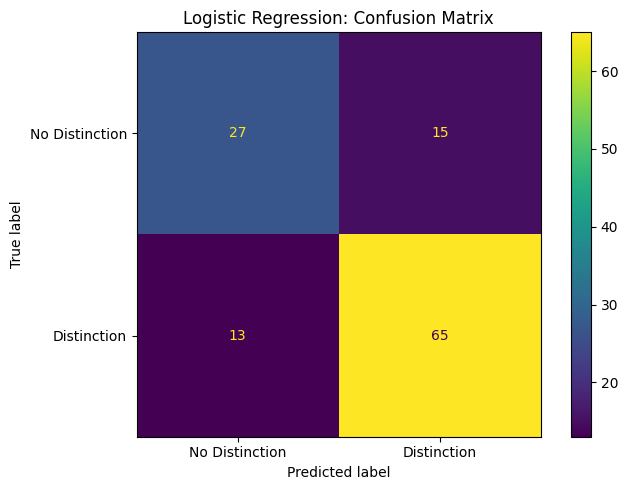

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(7, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test_cls,
    logistic_pred,
    display_labels=["No Distinction", "Distinction"],
    ax=ax
)

ax.set_title("Logistic Regression: Confusion Matrix")

fig.tight_layout()
fig.savefig("Figures/logistic_confusion_matrix.png", bbox_inches="tight")
plt.show()

### Interpretation

The confusion matrix shows that the Logistic Regression model correctly classified **27 students as No Distinction** and **65 students as Distinction**. It incorrectly classified **15 No Distinction students as Distinction** and **13 Distinction students as No Distinction**.

Overall, the model identified **65 out of 78 Distinction students** correctly, giving a recall of approximately **83.33%** for the Distinction class. It also correctly identified **27 out of 42 No Distinction students**, giving a recall of approximately **64.29%**.

The model performs better at identifying students who achieved Distinction than those who did not. This is consistent with the classification report, where the Distinction class has a higher F1-score (**0.82**) than the No Distinction class (**0.66**).

## 14. Direct Metric Improvements

Calculate exactly how much Logistic Regression changes each metric relative to the classification baseline.


In [24]:
classification_improvement = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "Baseline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
    ],
    "Logistic Regression": [
        logistic_accuracy,
        logistic_precision,
        logistic_recall,
        logistic_f1,
    ],
})

classification_improvement["Improvement"] = (
    classification_improvement["Logistic Regression"]
    - classification_improvement["Baseline"]
)

classification_improvement


,Metric,Baseline,Logistic Regression,Improvement
0,Accuracy,0.650000,0.766667,0.116667
1,Precision,0.650000,0.812500,0.162500
2,Recall,1.000000,0.833333,-0.166667
3,F1,0.787879,0.822785,0.034906


## Classification Model Improvement

The comparison shows that Logistic Regression improves overall classification performance compared with the most-frequent baseline.

Accuracy, precision, and F1-score increase, indicating that Logistic Regression makes more useful and balanced predictions.

Recall decreases compared with the baseline because the baseline predicts every student as the majority class, resulting in artificially perfect recall. Logistic Regression instead learns to distinguish between distinction and non-distinction students.

Overall, the improvement in accuracy, precision, and F1-score indicates that Logistic Regression is a more meaningful classifier than the baseline.

## Classifictaion Report

In [25]:
print("Classification report — Logistic Regression:")
print(classification_report(
    y_test_cls,
    logistic_pred,
    target_names=["No Distinction", "Distinction"],
    zero_division=0,
))


Classification report — Logistic Regression:
                precision    recall  f1-score   support

No Distinction       0.68      0.64      0.66        42
   Distinction       0.81      0.83      0.82        78

      accuracy                           0.77       120
     macro avg       0.74      0.74      0.74       120
  weighted avg       0.76      0.77      0.77       120



## Classification Report Interpretation

The classification report provides class-wise performance for the Logistic Regression model.

The model performs better on the Distinction class than on the No Distinction class. The Distinction class has stronger precision, recall, and F1-score, indicating that the model is more effective at identifying students who reach the distinction threshold.

The No Distinction class has lower recall, meaning that some students who do not reach the distinction threshold are incorrectly classified as distinction students.

The overall accuracy is around 77%, while the macro average provides an equal-weighted view of both classes and the weighted average accounts for their different class sizes.

Overall, the model provides reasonably balanced classification performance, with stronger results for predicting Distinction students.

## 15. Final Findings

The final conclusions below are generated from the actual metrics calculated above, rather than being hard-coded.


In [26]:
regression_winner = (
    linear_rmse < baseline_rmse and linear_r2 > baseline_r2
)

classification_winner = (
    logistic_f1 > baseline_f1
)

print("REGRESSION FINDING")
print(
    f"Linear Regression {'beats' if regression_winner else 'does not beat'} "
    f"the mean baseline: RMSE changes from {baseline_rmse:.4f} to "
    f"{linear_rmse:.4f}, while R² changes from {baseline_r2:.4f} to "
    f"{linear_r2:.4f}."
)

print("\nCOEFFICIENT FINDING")
print(
    f"The largest absolute Linear Regression coefficient is for "
    f"{largest_effect['Feature']}, with a coefficient of "
    f"{largest_effect['Coefficient']:.4f}."
)

print("\nCLASSIFICATION FINDING")
print(
    f"{distinction_fraction * 100:.2f}% of students meet the distinction "
    f"threshold (exam_score >= 85), so accuracy should be interpreted "
    f"together with precision, recall, and F1."
)

print("\nLOGISTIC REGRESSION FINDING")
print(
    f"Compared with the baseline, Logistic Regression changes accuracy by "
    f"{logistic_accuracy - baseline_accuracy:+.4f}, precision by "
    f"{logistic_precision - baseline_precision:+.4f}, recall by "
    f"{logistic_recall - baseline_recall:+.4f}, and F1 by "
    f"{logistic_f1 - baseline_f1:+.4f}."
)


REGRESSION FINDING
Linear Regression beats the mean baseline: RMSE changes from 10.2978 to 7.0584, while R² changes from -0.0096 to 0.5257.

COEFFICIENT FINDING
The largest absolute Linear Regression coefficient is for class_section_C, with a coefficient of 3.1304.

CLASSIFICATION FINDING
65.33% of students meet the distinction threshold (exam_score >= 85), so accuracy should be interpreted together with precision, recall, and F1.

LOGISTIC REGRESSION FINDING
Compared with the baseline, Logistic Regression changes accuracy by +0.1167, precision by +0.1625, recall by -0.1667, and F1 by +0.0349.


## 14. Reproducibility Check

This notebook uses:
- dataset seed = `21`
- regression split seed = `42`
- classification split seed = `42`
- Logistic Regression `random_state=21`

The full notebook is designed to run top-to-bottom after **Restart Kernel and Run All**, without manual reordering.


## Deliverable Summary

This notebook contains the complete baseline-to-first-model pipeline required for today:

1. One-hot encoded categorical features.
2. Fixed 80/20 regression train/test split.
3. Mean regression baseline with RMSE and R².
4. Linear Regression with RMSE and R².
5. Linear Regression coefficient analysis.
6. Binary distinction target at `exam_score >= 85`.
7. Fresh stratified classification split.
8. Most-frequent classification baseline with accuracy, precision, recall, and F1.
9. Logistic Regression with the same four metrics.
10. Direct baseline-vs-model metric comparisons.
11. Reproducible fixed-seed workflow.
